29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - kl_loss: 7.0215 - loss: 27.3668 - reconstruction_loss: 20.3453 - val_kl_loss: 7.9763 - val_loss: 33.8834 - val_reconstruction_loss: 25.9070
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - kl_loss: 7.9685 - loss: 27.4274 - reconstruction_loss: 19.4588 - val_kl_loss: 8.3506 - val_loss: 31.7925 - val_reconstruction_loss: 23.4418
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - kl_loss: 7.5058 - loss: 26.8231 - reconstruction_loss: 19.3172 - val_kl_loss: 7.9649 - val_loss: 30.8511 - val_reconstruction_loss: 22.8862
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - kl_loss: 7.8949 - loss: 25.8295 - reconstruction_loss: 17.9346 - val_kl_loss: 8.4378 - val_loss: 29.7604 - val_reconstruction_loss: 21.3226
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━

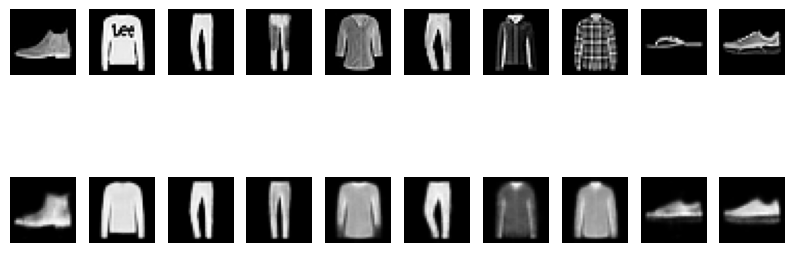

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


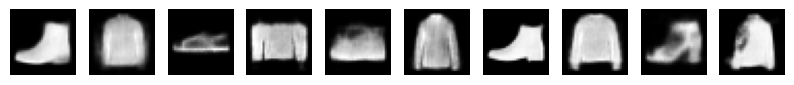

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


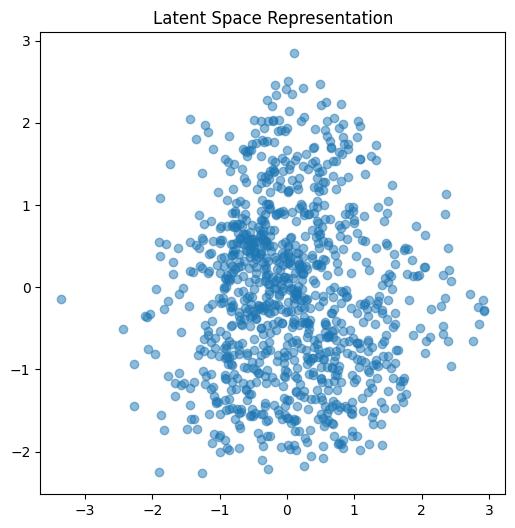

In [1]:
# =====================================
# 1. IMPORT LIBRARIES
# =====================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, datasets, losses, optimizers
import tensorflow.keras.backend as K


# =====================================
# 2. LOAD DATA
# =====================================
(x_train, _), (x_test, _) = datasets.fashion_mnist.load_data()


# =====================================
# 3. PREPROCESS DATA
# =====================================
def preprocess(imgs):
    imgs = imgs.astype("float32") / 255.0
    imgs = np.pad(imgs, ((0, 0), (2, 2), (2, 2)))  # 28 → 32
    imgs = np.expand_dims(imgs, -1)
    return imgs

x_train = preprocess(x_train)
x_test = preprocess(x_test)


# =====================================
# 4. SAMPLING LAYER
# =====================================
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


# =====================================
# 5. ENCODER
# =====================================
latent_dim = 16

encoder_input = layers.Input(shape=(32, 32, 1))

x = layers.Conv2D(32, 3, strides=2, activation="relu", padding="same")(encoder_input)
x = layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)

shape_before_flatten = K.int_shape(x)[1:]  # (4,4,128)

x = layers.Flatten()(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

z = Sampling()([z_mean, z_log_var])

encoder = models.Model(encoder_input, [z_mean, z_log_var, z], name="encoder")


# =====================================
# 6. DECODER
# =====================================
decoder_input = layers.Input(shape=(latent_dim,))

units = int(np.prod(shape_before_flatten))

x = layers.Dense(units)(decoder_input)
x = layers.Reshape(shape_before_flatten)(x)

x = layers.Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)

decoder_output = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

decoder = models.Model(decoder_input, decoder_output, name="decoder")


# =====================================
# 7. VAE MODEL
# =====================================
class VAE(models.Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def compute_loss(self, x, reconstruction, z_mean, z_log_var):

        # Reconstruction loss (MSE)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - reconstruction), axis=(1,2,3))
        )

        # KL Divergence
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
        )

        beta = 1
        total_loss = recon_loss + beta * kl_loss

        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            total_loss, recon_loss, kl_loss = self.compute_loss(
                data, reconstruction, z_mean, z_log_var
            )

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss,
        }

    def test_step(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        total_loss, recon_loss, kl_loss = self.compute_loss(
            data, reconstruction, z_mean, z_log_var
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss,
        }


vae = VAE(encoder, decoder)


# =====================================
# 8. TRAIN MODEL
# =====================================
vae.compile(optimizer=optimizers.Adam(learning_rate=0.0005))

vae.fit(
    x_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, None)
)


# =====================================
# 9. RECONSTRUCTION RESULTS
# =====================================
z_mean, z_log_var, z = encoder.predict(x_test[:10])
reconstructed = decoder.predict(z)

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.show()


# =====================================
# 10. GENERATE NEW IMAGES (IMPORTANT)
# =====================================
n = 10
z_sample = np.random.normal(size=(n, latent_dim))

generated_images = decoder.predict(z_sample)

plt.figure(figsize=(10, 2))
for i in range(n):
    plt.subplot(1, n, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()


# =====================================
# 11. LATENT SPACE VISUALIZATION
# =====================================
z_mean, _, _ = encoder.predict(x_test[:1000])

plt.figure(figsize=(6,6))
plt.scatter(z_mean[:,0], z_mean[:,1], alpha=0.5)
plt.title("Latent Space Representation")
plt.show()

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 0.0290 - val_loss: 0.0136
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0111 - val_loss: 0.0096
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0087 - val_loss: 0.0081
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0076 - val_loss: 0.0073
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0069 - val_loss: 0.0067
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0065 - val_loss: 0.0064
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0059 - val_loss: 0.0059
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0057 - val_loss: 0.0058
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0055 - val_loss: 0.0056
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step


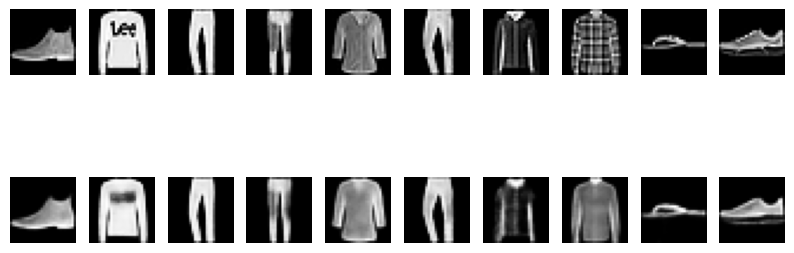

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


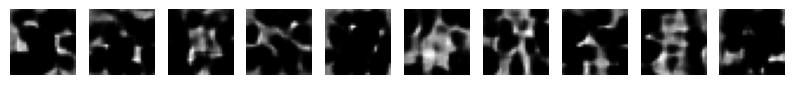

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step


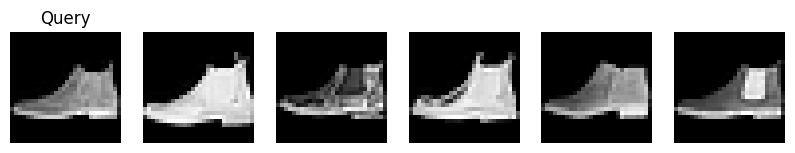

In [2]:
# =====================================
# 1. IMPORT LIBRARIES
# =====================================
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
from sklearn.metrics.pairwise import cosine_similarity


# =====================================
# 2. LOAD DATA
# =====================================
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()


# =====================================
# 3. PREPROCESS
# =====================================
def preprocess(imgs):
    imgs = imgs.astype("float32") / 255.0
    imgs = np.expand_dims(imgs, -1)
    return imgs

x_train = preprocess(x_train)
x_test = preprocess(x_test)


# =====================================
# 4. SIMPLE AUTOENCODER (FAST + SAFE)
# =====================================
latent_dim = 64

# Encoder
encoder_input = layers.Input(shape=(28,28,1))
x = layers.Conv2D(32,3,activation='relu',padding='same')(encoder_input)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
latent = layers.Dense(latent_dim)(x)

encoder = models.Model(encoder_input, latent)

# Decoder
decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(7*7*64)(decoder_input)
x = layers.Reshape((7,7,64))(x)
x = layers.Conv2DTranspose(64,3,strides=2,activation='relu',padding='same')(x)
x = layers.Conv2DTranspose(32,3,strides=2,activation='relu',padding='same')(x)
decoder_output = layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)

decoder = models.Model(decoder_input, decoder_output)

# Autoencoder
autoencoder = models.Model(encoder_input, decoder(encoder(encoder_input)))
autoencoder.compile(optimizer='adam', loss='mse')


# =====================================
# 5. TRAIN MODEL
# =====================================
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=128,
                validation_data=(x_test, x_test))


# =====================================
# 6. RECONSTRUCTION
# =====================================
encoded_imgs = encoder.predict(x_test[:10])
decoded_imgs = decoder.predict(encoded_imgs)

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()


# =====================================
# 7. GENERATE NEW IMAGES
# =====================================
random_latent = np.random.normal(size=(10, latent_dim))
generated = decoder.predict(random_latent)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(generated[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()


# =====================================
# 8. RECOMMENDATION SYSTEM
# =====================================
# Extract features
train_features = encoder.predict(x_train[:1000])

# Take a test image
test_img = x_test[0].reshape(1,28,28,1)
test_feature = encoder.predict(test_img)

# Compute similarity
similarities = cosine_similarity(test_feature, train_features)

# Get top 5 similar
top_indices = np.argsort(similarities[0])[-5:]

plt.figure(figsize=(10,2))

# Show query image
plt.subplot(1,6,1)
plt.imshow(x_test[0].squeeze(), cmap='gray')
plt.title("Query")
plt.axis('off')

# Show similar images
for i, idx in enumerate(top_indices):
    plt.subplot(1,6,i+2)
    plt.imshow(x_train[idx].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()